In [1]:

from google.colab import files
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
print(f'Successfully loaded {len(df)} individual lead interaction records.')

Saving ed38976-edd_cleaned.csv to ed38976-edd_cleaned.csv
Successfully loaded 14101 individual lead interaction records.


In [2]:

df['watch_ratio'] = np.clip(
    df['time_watched'] / np.maximum(df['video_duration'], 1.0), 0.0, 1.0
)
df['engagement_score'] = 1.0 - np.clip(df['disengagement_score'], 0.0, 1.0)
df['normalized_rating'] = np.clip((df['ratings'] - 1.0) / 4.0, 0.0, 1.0)
df['skip_penalty'] = np.clip(df['skip_count'] / 10.0, 0.0, 1.0)

df['is_high_intent'] = (
    (df['completion_status'] == True) & (df['disengagement_score'] <= 0.4)
).astype(int)

feature_cols = [
    'age',
    'ratings',
    'time_spent_on_course',
    'watch_ratio',
    'engagement_score',
    'normalized_rating',
    'skip_count',
    'pause_count',
    'experience_level_encoded',
    'learning_style_encoded',
    'difficulty_level_encoded',
    'category_encoded',
]

X = df[feature_cols]
y = df['is_high_intent']

print('Feature matrix shape:', X.shape)
print('High intent leads distribution:\n', y.value_counts(normalize=True))

Feature matrix shape: (14101, 12)
High intent leads distribution:
 is_high_intent
0    0.642011
1    0.357989
Name: proportion, dtype: float64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(f'Test AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}') # models ability to rank a pos lead higher than a neg lead
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


joblib.dump(clf, 'lead_scoring_model.joblib')
print("Model saved to 'lead_scoring_model.joblib'")

Test AUC-ROC Score: 0.9979

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1811
           1       0.96      0.96      0.96      1010

    accuracy                           0.97      2821
   macro avg       0.97      0.97      0.97      2821
weighted avg       0.97      0.97      0.97      2821

Model saved to 'lead_scoring_model.joblib'


In [4]:

df['ml_intent_prob'] = clf.predict_proba(X)[:, 1]

#  Heuristic Index
heuristic_index = (
    df['watch_ratio'] * 0.35
    + df['engagement_score'] * 0.35
    + df['normalized_rating'] * 0.20
    + (1.0 - df['skip_penalty']) * 0.10
)
df['lead_score'] = (
    (0.50 * df['ml_intent_prob'] + 0.50 * heuristic_index) * 100
).round(1)


def assign_priority(score):
  if score >= 75:
    return pd.Series(
        ['P1_HOT', 'Direct Outbound Call / Priority WhatsApp Offer']
    )
  elif score >= 50:
    return pd.Series(['P2_WARM', 'Automated Email Drip + Demo Class Invite'])
  else:
    return pd.Series(['P3_COLD', 'Drip Re-engagement / Free Masterclass'])


df[['priority_tier', 'counsellor_action']] = df['lead_score'].apply(
    assign_priority
)

print('Priority Tier Distribution:')
print(df['priority_tier'].value_counts())

Priority Tier Distribution:
priority_tier
P3_COLD    8841
P1_HOT     4786
P2_WARM     474
Name: count, dtype: int64



 TOP 10 LEADS FOR IMMEDIATE COUNSELOR ENGAGEMENT 


,student_id,name,age,course_name,category,lead_score,priority_tier,counsellor_action
10287,1b13ee4d-cae5-4825-a92a-803db71e8eff,Sherry Perez,44.0,Statistics for ML,Data Science,97.4,P1_HOT,Direct Outbound Call / Priority WhatsApp Offer
9011,fb273989-03c1-4963-9683-4fba64cfb410,Regina Wade,36.0,Advanced Penetration Testing,Cybersecurity,96.7,P1_HOT,Direct Outbound Call / Priority WhatsApp Offer
1031,172ae67b-b335-4ab1-a2a7-129c734989ff,Ms. Heather Rodriguez,48.0,Cybersecurity Fundamentals,Cybersecurity,96.5,P1_HOT,Direct Outbound Call / Priority WhatsApp Offer
10286,c21536ae-1a48-43fe-903b-639a999ad1ca,Alejandra Mcdonald,32.0,Advanced Penetration Testing,Cybersecurity,96.5,P1_HOT,Direct Outbound Call / Priority WhatsApp Offer
6404,cb86c3a3-84a6-4277-a5db-e6654ad26b6f,Victoria Joyce,32.0,React and Redux,Web Development,96.5,P1_HOT,Direct Outbound Call / Priority WhatsApp Offer
5680,7dd34e05-2561-4c2c-9508-23e99b3bfab8,Thomas Taylor PhD,29.0,React and Redux,Web Development,96.5,P1_HOT,Direct Outbound Call / Priority WhatsApp Offer
6521,055e5a37-529d-4b70-8804-9dcf2c416194,Phillip Thompson,23.0,Certified Ethical Hacker (CEH),Cybersecurity,96.5,P1_HOT,Direct Outbound Call / Priority WhatsApp Offer
6849,b87e67b0-c812-4d95-b96c-94e25ce6ff32,Zachary Hoover,47.0,Full Stack Web Development,Web Development,96.5,P1_HOT,Direct Outbound Call / Priority WhatsApp Offer
6798,35fdcb34-bf37-49cf-82bc-dcb40e54e5d9,Alexander Bailey,39.0,Backend APIs with Node.js,Web Development,96.3,P1_HOT,Direct Outbound Call / Priority WhatsApp Offer
6501,d53f886d-517b-4261-826e-445804947a6f,Andrew Evans,46.0,Computer Vision with OpenCV,AI,96.1,P1_HOT,Direct Outbound Call / Priority WhatsApp Offer


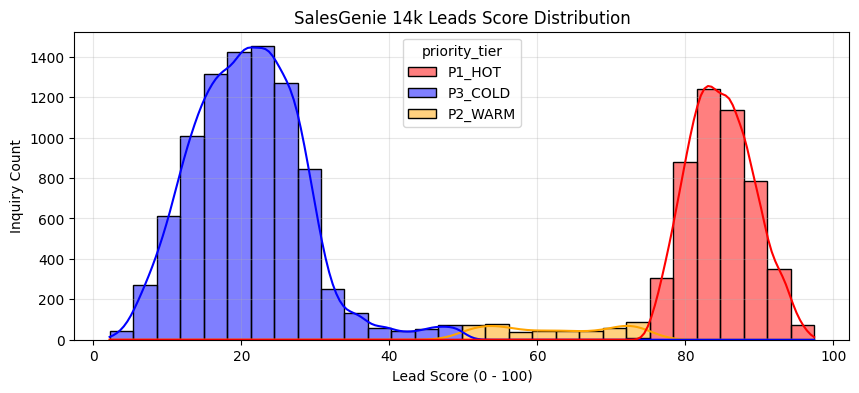

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:

counselor_queue = df.sort_values(by='lead_score', ascending=False)[
    [
        'student_id',
        'name',
        'age',
        'course_name',
        'category',
        'lead_score',
        'priority_tier',
        'counsellor_action',
    ]
]

print('\n TOP 10 LEADS FOR IMMEDIATE COUNSELOR ENGAGEMENT ')
display(counselor_queue.head(10))

plt.figure(figsize=(10, 4))
sns.histplot(
    data=df,
    x='lead_score',
    hue='priority_tier',
    bins=30,
    kde=True,
    palette={'P1_HOT': 'red', 'P2_WARM': 'orange', 'P3_COLD': 'blue'},
)
plt.title('SalesGenie 14k Leads Score Distribution')
plt.xlabel('Lead Score (0 - 100)')
plt.ylabel('Inquiry Count')
plt.grid(alpha=0.3)
plt.show()

# Download ranked dataset
counselor_queue.to_csv('ranked_counselor_14k_leads.csv', index=False)
files.download('ranked_counselor_14k_leads.csv')

In [6]:
import numpy as np
import pandas as pd


def test_single_student(student_data: dict):

  watch_ratio = np.clip(
      student_data['time_watched']
      / max(student_data['video_duration'], 1.0),
      0.0,
      1.0,
  )
  engagement_score = 1.0 - np.clip(
      student_data['disengagement_score'], 0.0, 1.0
  )
  normalized_rating = np.clip((student_data['ratings'] - 1.0) / 4.0, 0.0, 1.0)
  skip_penalty = np.clip(student_data['skip_count'] / 10.0, 0.0, 1.0)

  features_df = pd.DataFrame([{
      'age': student_data['age'],
      'ratings': student_data['ratings'],
      'time_spent_on_course': student_data['time_spent_on_course'],
      'watch_ratio': watch_ratio,
      'engagement_score': engagement_score,
      'normalized_rating': normalized_rating,
      'skip_count': student_data['skip_count'],
      'pause_count': student_data['pause_count'],
      'experience_level_encoded': student_data['experience_level_encoded'],
      'learning_style_encoded': student_data['learning_style_encoded'],
      'difficulty_level_encoded': student_data['difficulty_level_encoded'],
      'category_encoded': student_data['category_encoded'],
  }])

  #  Predict ML Intent Probability
  ml_prob = clf.predict_proba(features_df)[0, 1]

  heuristic_index = (
      watch_ratio * 0.35
      + engagement_score * 0.35
      + normalized_rating * 0.20
      + (1.0 - skip_penalty) * 0.10
  )

  lead_score = round(float((0.50 * ml_prob + 0.50 * heuristic_index) * 100), 1)

  if lead_score >= 75:
    tier = '🔥 P1_HOT'
    action = 'Direct Outbound Call / Priority WhatsApp Offer'
  elif lead_score >= 50:
    tier = '⚡ P2_WARM'
    action = 'Automated Email Drip + Demo Class Invite'
  else:
    tier = '❄️ P3_COLD'
    action = 'Drip Re-engagement / Free Masterclass'

  print(f"=== LEAD SCORE REPORT FOR: {student_data['name']} ===")
  print(f"Enrolled Course      : {student_data['course_name']}")
  print(f'AI Conversion Prob   : {ml_prob * 100:.1f}%')
  print(f'Behavior Index       : {heuristic_index * 100:.1f}%')
  print(f'Final Lead Score     : {lead_score} / 100')
  print(f'Priority Tier        : {tier}')
  print(f'Counselor Directive  : {action}\n')


# Test Case 1: High Engagement Student (Expected: Hot Lead)

student_hot = {
    'name': 'Rahul Sharma',
    'course_name': 'Full Stack Web Development',
    'age': 24,
    'ratings': 4.8,  # High rating
    'time_spent_on_course': 450.0,
    'video_duration': 300.0,
    'time_watched': 285.0,  # 95% watch ratio
    'skip_count': 1.0,  # Low skipping
    'pause_count': 3.0,
    'disengagement_score': 0.15,  # Low disengagement
    'experience_level_encoded': 1,
    'learning_style_encoded': 1,
    'difficulty_level_encoded': 2,
    'category_encoded': 3,
}

# Test Case 2: Low Engagement Student (Expected: Cold Lead)

student_cold = {
    'name': 'Ananya Verma',
    'course_name': 'Data Science Bootcamp',
    'age': 29,
    'ratings': 2.0,  # Low rating
    'time_spent_on_course': 40.0,
    'video_duration': 400.0,
    'time_watched': 30.0,  # 7.5% watch ratio
    'skip_count': 8.0,  # Excessive skipping
    'pause_count': 1.0,
    'disengagement_score': 0.85,  # High disengagement
    'experience_level_encoded': 0,
    'learning_style_encoded': 2,
    'difficulty_level_encoded': 1,
    'category_encoded': 2,
}

test_single_student(student_hot)
test_single_student(student_cold)

=== LEAD SCORE REPORT FOR: Rahul Sharma ===
Enrolled Course      : Full Stack Web Development
AI Conversion Prob   : 98.2%
Behavior Index       : 91.0%
Final Lead Score     : 94.6 / 100
Priority Tier        : 🔥 P1_HOT
Counselor Directive  : Direct Outbound Call / Priority WhatsApp Offer

=== LEAD SCORE REPORT FOR: Ananya Verma ===
Enrolled Course      : Data Science Bootcamp
AI Conversion Prob   : 0.1%
Behavior Index       : 14.9%
Final Lead Score     : 7.5 / 100
Priority Tier        : ❄️ P3_COLD
Counselor Directive  : Drip Re-engagement / Free Masterclass



In [7]:
# Change the dump line in Cell 3:
joblib.dump(clf, "lead_scoring_model.pkl")

['lead_scoring_model.pkl']